# ISS – Numerical Exercise 5: Random Processes
## Náhodné procesy / Random processes

**Author:** Honza Černocký, FIT VUT Brno  
**Date:** November 17, 2022

**Reference solution:**  
https://docs.google.com/spreadsheets/d/1nHIagKkjWdiCtCwTyv89aYsroQm9q6r83algrz2OP0o/edit?usp=sharing

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---
## 1. Souborové odhady parametrů / Ensemble estimates of parameters

Máme k disposici $\Omega = 10$ realizací náhodného procesu s diskrétním časem. Pro čas $n = 5$ měly realizace tyto hodnoty $\xi_\omega[n]$:

In [2]:
# Data for n=5
xi_5 = np.array([2.2, 1.2, 2.5, 2.3, 4.1, 2.5, 2.8, 3.3, 2.5, 1.7])
Omega = len(xi_5)  # Number of realizations
print(f"Realizations for n=5: {xi_5}")
print(f"Number of realizations Ω = {Omega}")

Realizations for n=5: [2.2 1.2 2.5 2.3 4.1 2.5 2.8 3.3 2.5 1.7]
Number of realizations Ω = 10


### Problem 1: Estimate the mean value a[n] for n = 5

Odhadněte střední hodnotu $a[n]$ pro $n = 5$

#### Řešení / Solution

**Střední hodnota** (mean value) je definována jako:

$$a[n] = \frac{1}{\Omega} \sum_{\omega=1}^{\Omega} \xi_\omega[n]$$

kde:
- $\Omega$ je počet realizací náhodného procesu
- $\xi_\omega[n]$ je hodnota $\omega$-té realizace v čase $n$
- $a[n]$ je odhad střední hodnoty v čase $n$

Střední hodnota udává "průměrnou" hodnotu náhodné veličiny.

In [3]:
# Solution 1
a_5 = np.mean(xi_5)
print(f"Mean value a[5] = {a_5}")

Mean value a[5] = 2.51


### Problem 2: Estimate the dispersion D[n] for n = 5

Odhadněte rozptyl $D[n]$ pro $n = 5$

#### Řešení / Solution

**Rozptyl** (dispersion, variance) je definován jako:

$$D[n] = \frac{1}{\Omega} \sum_{\omega=1}^{\Omega} (\xi_\omega[n] - a[n])^2$$

kde:
- $a[n]$ je střední hodnota
- $D[n]$ udává, jak moc se hodnoty "rozptylují" kolem střední hodnoty
- Čím větší rozptyl, tím více se hodnoty liší od průměru

In [4]:
# Solution 2
D_5 = np.var(xi_5, ddof=0)  # ddof=0 for population variance (biased estimate)
print(f"Dispersion D[5] = {D_5}")

Dispersion D[5] = 0.5748999999999997


### Problem 3: Estimate the standard deviation σ[n] for n = 5

Odhadněte směrodatnou odchylku $\sigma[n]$ pro $n = 5$

#### Řešení / Solution

**Směrodatná odchylka** (standard deviation, RMS - root mean square) je definována jako:

$$\sigma[n] = \sqrt{D[n]} = \sqrt{\frac{1}{\Omega} \sum_{\omega=1}^{\Omega} (\xi_\omega[n] - a[n])^2}$$

kde:
- $\sigma[n]$ je odmocnina z rozptylu
- Má stejné jednotky jako původní data (na rozdíl od rozptylu)
- Udává "typickou" odchylku od střední hodnoty

In [5]:
# Solution 3
sigma_5 = np.std(xi_5, ddof=0)  # ddof=0 for population std (biased estimate)
print(f"Standard deviation σ[5] = {sigma_5}")
print(f"Verification: σ[5] = √D[5] = {np.sqrt(D_5)}")

Standard deviation σ[5] = 0.7582216034906943
Verification: σ[5] = √D[5] = 0.7582216034906943


### Problem 4: Assume the signal is stationary. Estimate the same parameters for time n = 7

Předpokládejte, že je signál **stacionární**. Odhadněte tytéž parametry pro čas $n = 7$

#### Řešení / Solution

**Stacionární signál** má statistické vlastnosti nezávislé na čase:

$$a[n] = a[n+k] = \text{konst.}$$
$$D[n] = D[n+k] = \text{konst.}$$
$$\sigma[n] = \sigma[n+k] = \text{konst.}$$

Pro stacionární signál platí, že střední hodnota, rozptyl a směrodatná odchylka **nezávisí na čase** $n$.

In [6]:
# Solution 4
# For a stationary signal, the parameters do not depend on time
a_7 = a_5
D_7 = D_5
sigma_7 = sigma_5

print(f"For stationary signal at n=7:")
print(f"Mean value a[7] = {a_7}")
print(f"Dispersion D[7] = {D_7}")
print(f"Standard deviation σ[7] = {sigma_7}")

For stationary signal at n=7:
Mean value a[7] = 2.51
Dispersion D[7] = 0.5748999999999997
Standard deviation σ[7] = 0.7582216034906943


---
## 2. Distribuční funkce / Cumulative probability distribution function

### Problem 5: Estimate the CPDF F(x,n) for n = 5. Recommended step on x axis is 0.5

Odhadněte distribuční funkci $F(x, n)$ pro $n = 5$. Doporučený krok na ose $x$ je 0.5

#### Řešení / Solution

**Distribuční funkce** (cumulative probability distribution function - CPDF) je definována jako:

$$F(x, n) = P\{\xi[n] < x\}$$

Vlastnosti:

* Je neklesající a nabývá hodnot v intervalu  [0,1].
* Má skoky v bodech, kde má X nenulovou pravděpodobnost.
* Pro diskrétní veličinu dále platí:
$$
F(x, n) = \sum_{t \le x} P(\xi[n] = t).
$$



Odhad:

$$\hat{F}(x, n) = \frac{\text{počet realizací, kde } \xi_\omega[n] < x}{\Omega}$$

kde:
- $F(x, n)$ udává pravděpodobnost, že hodnota náhodné veličiny bude **menší** než $x$
- $F(x, n)$ je neklesající funkce: $0 \leq F(x, n) \leq 1$

In [7]:
np.sort(xi_5)

array([1.2, 1.7, 2.2, 2.3, 2.5, 2.5, 2.5, 2.8, 3.3, 4.1])

x,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5
"F(x,5)",0.0,0.0,0.0,0.1,0.2,0.4,0.8,0.9,0.9,1.0


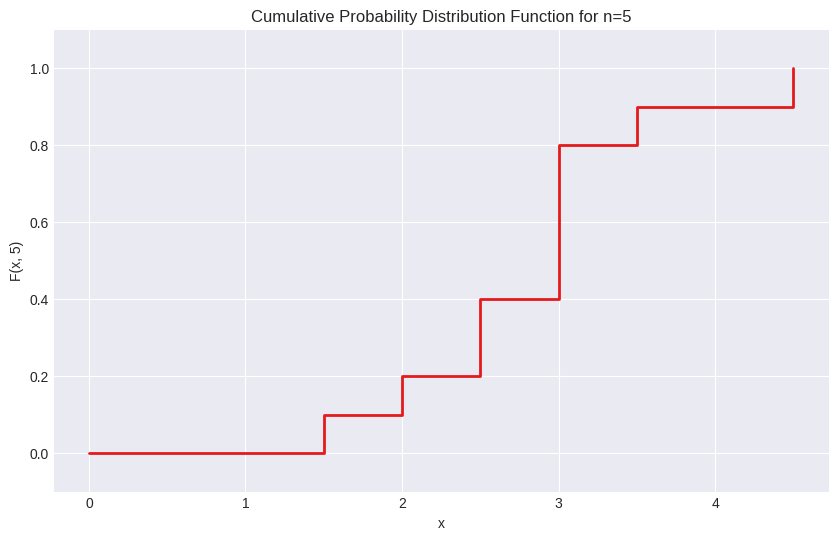

In [8]:
# Solution 5
# Create x values with step 0.5
x_values = np.arange(0, 5, 0.5)

# Calculate CPDF F(x, 5) = P{ξ[5] < x}
F_x = np.array([np.sum(xi_5 < x) / Omega for x in x_values])

# Display results
cpdf_table = pd.DataFrame({'x': x_values, 'F(x,5)': F_x})
display(cpdf_table.set_index('x').T)

# Plot CPDF
plt.figure(figsize=(10, 6))
plt.step(x_values, F_x, where='post', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x, 5)')
plt.title('Cumulative Probability Distribution Function for n=5')
plt.grid(True)
plt.ylim([-0.1, 1.1])
plt.show()

### Problem 6: Determine the probability P{ξ[5] ≥ 2.5}

Určete pravděpodobnost $P\{\xi[5] \geq 2.5\}$

#### Řešení / Solution

Pravděpodobnost se odhadne jako poměr:

$$P\{\xi[5] \geq 2.5\} = \frac{\text{počet realizací, kde } \xi_\omega[5] \geq 2.5}{\Omega}$$

Alternativně pomocí distribuční funkce:

$$P\{\xi[5] \geq x\} = 1 - P\{\xi[5] < x\} = 1 - F(x, 5)$$

In [9]:
# Solution 6
P_geq_2_5 = np.sum(xi_5 >= 2.5) / Omega
print(f"P{{ξ[5] ≥ 2.5}} = {P_geq_2_5}")
print(f"Number of values ≥ 2.5: {np.sum(xi_5 >= 2.5)} out of {Omega}")

P{ξ[5] ≥ 2.5} = 0.6
Number of values ≥ 2.5: 6 out of 10


---
## 3. Funkce hustoty rozdělení pravděpodobnosti / Probability density function

### Problem 7: Divide the x axis into intervals, count and plot the counts. Recommended width: 0.5

Rozdělte osu $x$ na intevaly ("chlívky"), spočítejte a do grafu nakreslete **počty hodnot** (counts) v jednotlivých chlívcích

#### Řešení / Solution

**Histogram** rozdělí osu $x$ na intervaly (bins) a spočítá, kolik hodnot padlo do každého intervalu.

Pro interval $[x_i, x_{i+1})$:

$$\text{count}_i = \sum_{\omega=1}^{\Omega} \mathbb{1}\{x_i \leq \xi_\omega[n] < x_{i+1}\}$$

kde $\mathbb{1}\{\cdot\}$ je indikátorová funkce (1 pokud je podmínka splněna, jinak 0).

Bin,"[1.0, 1.5)","[1.5, 2.0)","[2.0, 2.5)","[2.5, 3.0)","[3.0, 3.5)","[3.5, 4.0)","[4.0, 4.5)"
Count,1,1,2,4,1,0,1


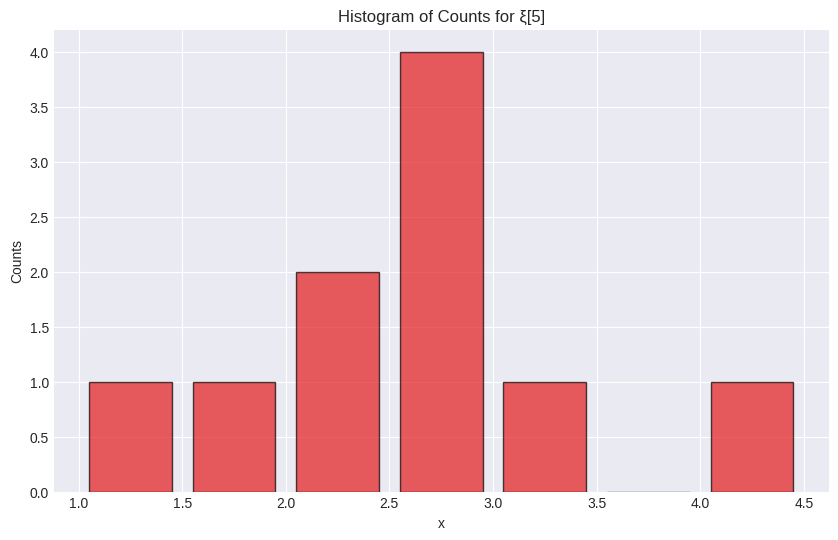

In [10]:
# Solution 7
bin_width = 0.5
bins = np.arange(1.0, 4.5 + bin_width, bin_width)

# Count values in each bin
counts, bin_edges = np.histogram(xi_5, bins=bins)

# Display counts
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
count_table = pd.DataFrame({
    'Bin': [f"[{bin_edges[i]:.1f}, {bin_edges[i+1]:.1f})" for i in range(len(counts))],
    'Count': counts
})
display(count_table.set_index('Bin').T)

# Plot histogram of counts
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, counts, width=bin_width*0.8, edgecolor='black', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Counts')
plt.title('Histogram of Counts for ξ[5]')
plt.grid(True, axis='y')
plt.show()

### Problem 8: Estimate and plot probabilities that the value ξ[5] will occur in given interval

Odhadněte a nakreslete **pravděpodobnosti**, že se bude hodnota $\xi[5]$ vyskytovat v daném chlívku

#### Řešení / Solution

Pravděpodobnost pro interval $[x_i, x_{i+1})$:

$$P\{x_i \leq \xi[n] < x_{i+1}\} = \frac{\text{count}_i}{\Omega}$$


Pravděpodobnost je **diskrétní**.

Bin,"[1.0, 1.5)","[1.5, 2.0)","[2.0, 2.5)","[2.5, 3.0)","[3.0, 3.5)","[3.5, 4.0)","[4.0, 4.5)"
Count,1.0,1.0,2.0,4.0,1.0,0.0,1.0
Probability,0.1,0.1,0.2,0.4,0.1,0.0,0.1


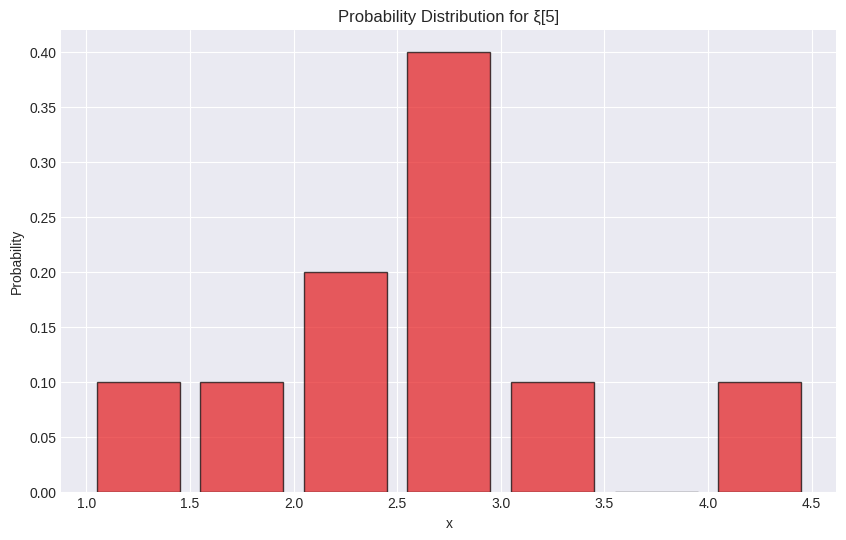

In [11]:
# Solution 8
probabilities = counts / Omega

# Display probabilities
prob_table = pd.DataFrame({
    'Bin': [f"[{bin_edges[i]:.1f}, {bin_edges[i+1]:.1f})" for i in range(len(counts))],
    'Count': counts,
    'Probability': probabilities
})
display(prob_table.set_index('Bin').T)

# Plot histogram of probabilities
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, probabilities, width=bin_width*0.8, edgecolor='black', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Probability Distribution for ξ[5]')
plt.grid(True, axis='y')
plt.show()

### Problem 9: Estimate and plot probability density function p(x,n) for n = 5

Odhadněte a nakreslete **funkci hustoty rozdělení pravděpodobnosti** $p(x, n)$ pro $n = 5$

#### Řešení / Solution

**Funkce hustoty pravděpodobnosti** (probability density function - PDF) se odhadne jako:

$$p(x, n) = \frac{P\{x_i \leq \xi[n] < x_{i+1}\}}{\Delta x}$$

kde:
- $\Delta x$ je šířka intervalu (bin width)
- $p(x, n)$ je **spojitá funkce**
- $\int_{-\infty}^{+\infty} p(x,n)dx = 1$. Proto také dělíme šířkou intervalu. Aby byl integrál roven 1 (tj. plocha pod křivkou).



Vztah k distribuční funkci:

$$p(x, n) = \frac{dF(x, n)}{dx}$$

Bin center x,1.25,1.75,2.25,2.75,3.25,3.75,4.25
Count,1.0,1.0,2.0,4.0,1.0,0.0,1.0
Probability,0.1,0.1,0.2,0.4,0.1,0.0,0.1
"p(x,5)",0.2,0.2,0.4,0.8,0.2,0.0,0.2


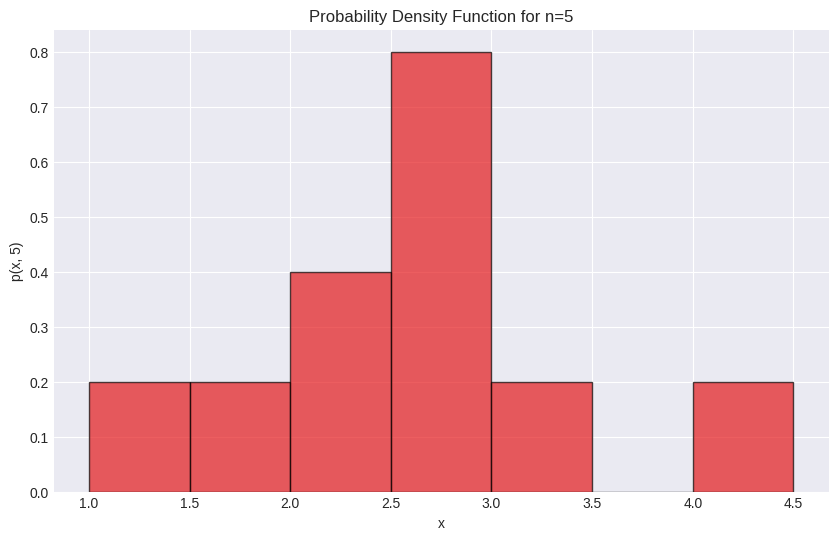

In [12]:
# Solution 9
# PDF is probability divided by bin width
pdf = probabilities / bin_width

# Display PDF
pdf_table = pd.DataFrame({
    'Bin center x': bin_centers,
    'Count': counts,
    'Probability': probabilities,
    'p(x,5)': pdf
})
display(pdf_table.set_index('Bin center x').T)

# Plot PDF
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, pdf, width=bin_width, edgecolor='black', alpha=0.7)
plt.xlabel('x')
plt.ylabel('p(x, 5)')
plt.title('Probability Density Function for n=5')
plt.grid(True, axis='y')
plt.show()

### Problem 10: Verify numerically that ∫ p(x,n)dx = 1

Ověřte numericky, že $\int_{-\infty}^{+\infty} p(x,n)dx = 1$

#### Řešení / Solution

**Normalizační podmínka** pro PDF:

$$\int_{-\infty}^{+\infty} p(x,n)dx = 1$$

Numerická integrace (obdélníková metoda):

$$\int p(x,n)dx \approx \sum_{i} p(x_i, n) \cdot \Delta x$$

In [13]:
# Solution 10
# Numerical integration: sum of p(x) * dx
integral = np.sum(pdf * bin_width)
print(f"∫ p(x,5)dx = {integral}")
print(f"Verification: Sum of probabilities = {np.sum(probabilities)}")

∫ p(x,5)dx = 1.0
Verification: Sum of probabilities = 1.0


### Problem 11: Numerically compute the mean value according to the definition formula

Numericky spočítejte střední hodnotu podle definičního vztahu:

$$a[n] = \int_{-\infty}^{+\infty} x \cdot p(x,n)dx$$

Porovnejte s odhadem střední hodnoty $a[n]$ z dat.

#### Řešení / Solution

**Střední hodnota z PDF**:

$$a[n] = \int_{-\infty}^{+\infty} x \cdot p(x,n)dx$$

Numerická integrace:

$$a[n] \approx \sum_{i} x_i \cdot p(x_i, n) \cdot \Delta x$$

In [14]:
# Solution 11
# Numerical integration: sum of x * p(x) * dx
a_5_numerical = np.sum(bin_centers * pdf * bin_width)
print(f"Mean value from PDF: a[5] = {a_5_numerical}")
print(f"Mean value from data: a[5] = {a_5}") # From ex.: 1
print(f"Difference: {abs(a_5_numerical - a_5)}")

Mean value from PDF: a[5] = 2.6000000000000005
Mean value from data: a[5] = 2.51
Difference: 0.09000000000000075


### Problem 12: Numerically compute the dispersion according to the definition formula

Numericky spočítejte rozptyl podle definičního vztahu:

$$D[n] = \int_{-\infty}^{+\infty} (x - a[n])^2 \cdot p(x,n)dx$$


Porovnejte s odhadem rozptylu $D[n]$ z dat.

#### Řešení / Solution

**Rozptyl z PDF**:

$$D[n] = \int_{-\infty}^{+\infty} (x - a[n])^2 \cdot p(x,n)dx$$

Numerická integrace:

$$D[n] \approx \sum_{i} (x_i - a[n])^2 \cdot p(x_i, n) \cdot \Delta x$$

In [15]:
# Solution 12
# Numerical integration: sum of (x - a)^2 * p(x) * dx
D_5_numerical = np.sum((bin_centers - a_5)**2 * pdf * bin_width)
print(f"Dispersion from PDF: D[5] = {D_5_numerical}")
print(f"Dispersion from data: D[5] = {D_5}")
print(f"Difference: {abs(D_5_numerical - D_5)}")

Dispersion from PDF: D[5] = 0.6106000000000001
Dispersion from data: D[5] = 0.5748999999999997
Difference: 0.0357000000000004


---
## 4. Sdružená funkce hustoty rozdělení pravděpodobnosti a korelační koeficient
## Joint probability density function and correlation coefficient

Na $\Omega = 10000$ realizacích byly zjištěny pro $n_1 = 5$ a $n_2 = 10$ tyto sdružené výskyty hodnot, tj. že se hodnota $\xi[n_1]$ vyskytla v intervalu hodnot $x_1$ v řádku tabulky a **pro stejnou realizaci** se vyskytla $\xi[n_2]$ v intervalu hodnot $x_2$ ve sloupci tabulky.

In [16]:
# Joint counts table (2D histogram)
# Rows: x1 intervals, Columns: x2 intervals
Omega_joint = 10000

# Define intervals
x1_intervals = ['-0.3...-0.2', '-0.2...-0.1', '-0.1...0', '0...0.1', '0.1...0.2', '0.2...0.3']
x2_intervals = ['-0.3...-0.2', '-0.2...-0.1', '-0.1...0', '0...0.1', '0.1...0.2', '0.2...0.3']

# Joint counts (from the table in PDF)
joint_counts = np.array([
    [   0,    0,    0,    0,    0, 1000],  # x1: 0.2...0.3
    [   0,    0,    0,  500, 1000,    0],  # x1: 0.1...0.2
    [   0,    0,  500, 1500,  500,    0],  # x1: 0.0...0.1
    [   0,  500, 1500,  500,    0,    0],  # x1: -0.1...0
    [   0, 1000,  500,    0,    0,    0],  # x1: -0.2...-0.1
    [1000,    0,    0,    0,    0,    0]   # x1: -0.3...-0.2
])

x1_intervals_display = x1_intervals[::-1]

# Display as table
joint_df = pd.DataFrame(joint_counts, 
                        index=x1_intervals_display,
                        columns=x2_intervals)
print("Joint counts table:")
display(joint_df)
print(f"\nTotal counts: {np.sum(joint_counts)}")

Joint counts table:


,-0.3...-0.2,-0.2...-0.1,-0.1...0,0...0.1,0.1...0.2,0.2...0.3
0.2...0.3,0,0,0,0,0,1000
0.1...0.2,0,0,0,500,1000,0
0...0.1,0,0,500,1500,500,0
-0.1...0,0,500,1500,500,0,0
-0.2...-0.1,0,1000,500,0,0,0
-0.3...-0.2,1000,0,0,0,0,0



Total counts: 10000


### Problem 13: Estimate joint probabilities

Odhadněte **sdružené pravděpodobnosti**, že se hodnota $\xi[n_1]$ vyskytla v intervalu hodnot $x_1$ v řádku tabulky **a zároveň** se vyskytla $\xi[n_2]$ v intervalu hodnot $x_2$ ve sloupci tabulky

#### Řešení / Solution

**Sdružená pravděpodobnost** (joint probability):

$$P\{x_{1,i} \leq \xi[n_1] < x_{1,i+1} \text{ a zároveň } x_{2,j} \leq \xi[n_2] < x_{2,j+1}\} = \frac{\text{count}_{i,j}}{\Omega}$$

Kde $\Omega=10~000$. Tedy **normalizuje** se, aby pro sdruženou pravděpodobnost platilo:

$$
\sum_{i}\sum_{j} P(x_{1,i}, x_{2,j}, n_1, n_2) = 1.
$$


In [17]:
# Solution 13
joint_prob = joint_counts / Omega_joint

# Display as table
joint_prob_df = pd.DataFrame(joint_prob,
                              index=x1_intervals_display,
                              columns=x2_intervals)
print("Joint probabilities table:")
display(joint_prob_df)
print(f"\nSum of all probabilities: {np.sum(joint_prob)}")

Joint probabilities table:


,-0.3...-0.2,-0.2...-0.1,-0.1...0,0...0.1,0.1...0.2,0.2...0.3
0.2...0.3,0.0,0.00,0.00,0.00,0.00,0.1
0.1...0.2,0.0,0.00,0.00,0.05,0.10,0.0
0...0.1,0.0,0.00,0.05,0.15,0.05,0.0
-0.1...0,0.0,0.05,0.15,0.05,0.00,0.0
-0.2...-0.1,0.0,0.10,0.05,0.00,0.00,0.0
-0.3...-0.2,0.1,0.00,0.00,0.00,0.00,0.0



Sum of all probabilities: 1.0


### Problem 14: Estimate joint probability density function p(x₁, x₂, n₁, n₂)

Odhadněte **sdruženou funkci hustoty rozdělení pravděpodobnosti** $p(x_1, x_2, n_1, n_2)$

#### Řešení / Solution

**Sdružená PDF** (joint PDF) pro dva rozměry:

$$p(x_1, x_2, n_1, n_2) = \frac{P\{x_{1,i} \leq \xi[n_1] < x_{1,i+1}, x_{2,j} \leq \xi[n_2] < x_{2,j+1}\}}{\Delta x_1 \cdot \Delta x_2}$$

kde:
- $\Delta x_1, \Delta x_2$ jsou šířky intervalů
- $\Delta x_1 \cdot \Delta x_2$ je plocha "chlívku" (bin area)
- $p(x_1, x_2, n_1, n_2)$ je spojitá funkce
- $\int_{x_1} \int_{x_2} p(x_1,x_2,n_1,n_2)dx_1dx_2 = 1$. Proto se dělí/normalizuje intervaly, aby byl integrál roven 1 (tj. objem pod plochou).



Joint PDF p(x₁, x₂, 5, 10):


,-0.3...-0.2,-0.2...-0.1,-0.1...0,0...0.1,0.1...0.2,0.2...0.3
0.2...0.3,0.0,0.0,0.0,0.0,0.0,10.0
0.1...0.2,0.0,0.0,0.0,5.0,10.0,0.0
0...0.1,0.0,0.0,5.0,15.0,5.0,0.0
-0.1...0,0.0,5.0,15.0,5.0,0.0,0.0
-0.2...-0.1,0.0,10.0,5.0,0.0,0.0,0.0
-0.3...-0.2,10.0,0.0,0.0,0.0,0.0,0.0


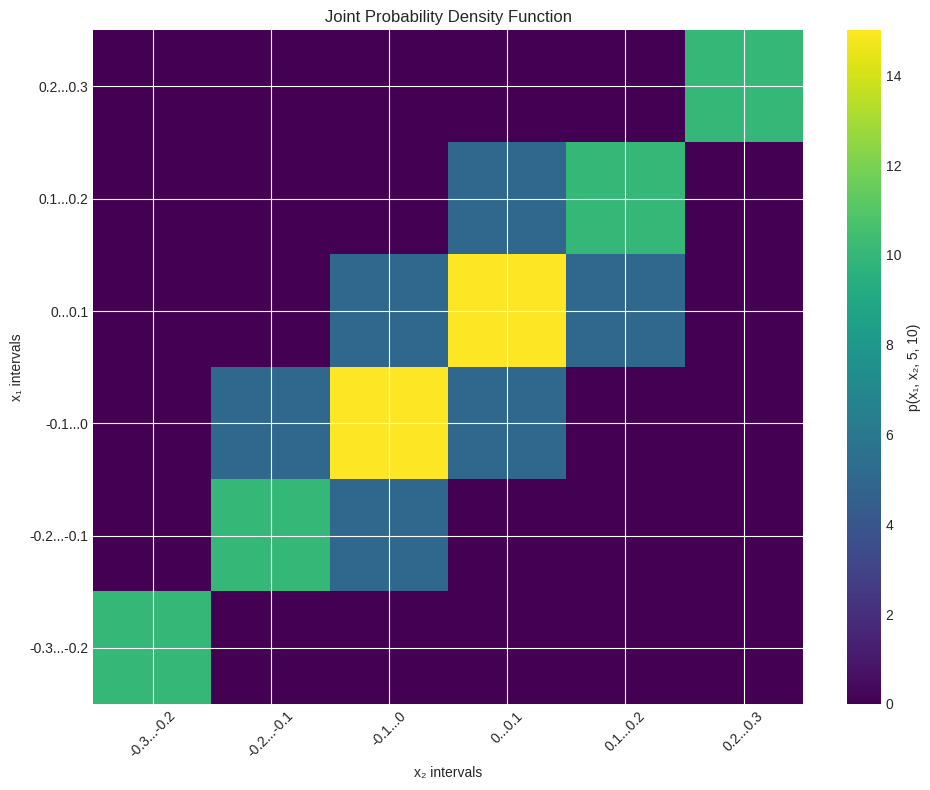

In [18]:
# Solution 14
# Joint PDF is joint probability divided by area of bin
delta_x1 = 0.1  # bin width for x1
delta_x2 = 0.1  # bin width for x2
bin_area = delta_x1 * delta_x2

joint_pdf = joint_prob / bin_area

# Display as table
joint_pdf_df = pd.DataFrame(joint_pdf,
                            index=x1_intervals_display,
                            columns=x2_intervals)
print("Joint PDF p(x₁, x₂, 5, 10):")
display(joint_pdf_df)

# Visualize as heatmap
plt.figure(figsize=(10, 8))
plt.imshow(joint_pdf, cmap='viridis', aspect='auto')
plt.colorbar(label='p(x₁, x₂, 5, 10)')
plt.xlabel('x₂ intervals')
plt.ylabel('x₁ intervals')
plt.title('Joint Probability Density Function')
plt.xticks(range(len(x2_intervals)), x2_intervals, rotation=45)
plt.yticks(range(len(x1_intervals_display)), x1_intervals_display)
plt.tight_layout()
plt.show()

### Problem 15: Verify numerically that ∫∫ p(x₁,x₂,n₁,n₂)dx₁dx₂ = 1

Ověřte numericky že $\iint p(x_1,x_2,n_1,n_2)dx_1dx_2 = 1$

#### Řešení / Solution

**Normalizační podmínka pro sdruženou PDF**:

$$\int_{x_1} \int_{x_2} p(x_1,x_2,n_1,n_2)dx_1dx_2 = 1$$

Numerická integrace:

$$\iint p(x_1,x_2,n_1,n_2)dx_1dx_2 \approx \sum_{i,j} p(x_{1,i}, x_{2,j}, n_1, n_2) \cdot \Delta x_1 \cdot \Delta x_2$$

In [19]:
# Solution 15
# Double integration: sum of p(x1, x2) * dx1 * dx2
double_integral = np.sum(joint_pdf * bin_area)
print(f"∫∫ p(x₁,x₂,5,10)dx₁dx₂ = {double_integral}")
print(f"Verification: Sum of joint probabilities = {np.sum(joint_prob)}")

∫∫ p(x₁,x₂,5,10)dx₁dx₂ = 1.0
Verification: Sum of joint probabilities = 1.0


### Problem 16: Estimate correlation coefficient R(5, 10)

Odhadněte **korelační koeficient** $R(5, 10)$ pomocí:

$$R[n_1, n_2] = \int_{x_1} \int_{x_2} p(x_1,x_2,n_1,n_2) \cdot x_1 \cdot x_2 \, dx_1 dx_2$$

Korelační koeficient $R[n_1,n_2]$ vyjadřuje míru toho,
**jak silně jsou spolu spojeny hodnoty náhodné veličiny**
$\xi[n_1]$ a $\xi[n_2]$. 

Pokud je $R[n_1,n_2]$ velké a kladné, znamená to, že když je
$\xi[n_1]$ velká, bývá velká i $\xi[n_2]$.
Pokud je naopak záporný, pak když je $\xi[n_1]$ velká,
$\xi[n_2]$ bývá malá.

Hodnota blízká nule znamená, že mezi veličinami není
výrazná **lineární závislost**.

Korelační koeficient je tedy střední hodnota součinu obou veličin
a popisuje jejich vzájemnou závislost.

#### Řešení / Solution

**Korelační koeficient** (correlation coefficient) měří statistickou závislost mezi dvěma náhodnými veličinami:

$$R[n_1, n_2] = \int_{x_1} \int_{x_2} p(x_1,x_2,n_1,n_2) \cdot x_1 \cdot x_2 \, dx_1 dx_2$$

Numerická integrace:

$$R[n_1, n_2] \approx \sum_{i}\sum_{j} p(x_{1,i}, x_{2,j}, n_1, n_2) \cdot x_{1,i} \cdot x_{2,j} \cdot \Delta x_1 \cdot \Delta x_2$$

- Pokud $R[n_1, n_2] > 0$: pozitivní korelace
- Pokud $R[n_1, n_2] < 0$: negativní korelace
- Pokud $R[n_1, n_2] \approx 0$: náhodné veličiny jsou nekorelované

In [20]:
# Solution 16
# Define bin centers for x1 and x2
x1_centers = np.array([-0.25, -0.15, -0.05, 0.05, 0.15, 0.25])[::-1] # Rows
x2_centers = np.array([-0.25, -0.15, -0.05, 0.05, 0.15, 0.25])       # Columns

# Create meshgrid. Basically 2D arrays representing
# Rows and Columns coordinates in 2D space for each point.
X1, X2 = np.meshgrid(x2_centers, x1_centers)

# Calculate correlation coefficient A)
R_5_10_A = np.sum(joint_pdf * X1 * X2 * bin_area)

# OR B)
R_5_10_B = np.sum(joint_pdf * x1_centers[:, None] * x2_centers[None, :] * bin_area)

print(f"B) Correlation coefficient R(5, 10) = {R_5_10_A}")
print(f"A) Correlation coefficient R(5, 10) = {R_5_10_B}")

B) Correlation coefficient R(5, 10) = 0.019
A) Correlation coefficient R(5, 10) = 0.019


---
## 5. Časové odhady / Temporal estimates

Jedna realizace **ergodického** náhodného signálu má $N = 6$ vzorků o hodnotách (pro $n = 0 \ldots 5$):

#### Řešení / Solution


**Ergodický signál** je takový, u kterého statistiky vypočítané z jednoho časového úseku signálu (např. průměrná amplituda, variance, korelace) odpovídají statistikám, které bychom získali, kdybychom měli k dispozici všechny možné realizace tohoto signálu.

Příklad:

* Pokud analyzuji energie signálu nebo autokorelační funkci audio signálu a předpokládám, že je ergodický, mohu vzít jeden úsek a použít jeho průměry a korelace k odhadu vlastností celého audia.

Takže v zásadě: ergodicita nám dovoluje nahradit „mnoho vzorků“ časovým průměrem jediného signálu, což je praktické při práci se signály.

In [21]:
# Signal data
x = np.array([2, 4, 2, 0, -2, -4])
N = len(x)
print(f"Signal x[n] = {x}")
print(f"Number of samples N = {N}")

Signal x[n] = [ 2  4  2  0 -2 -4]
Number of samples N = 6


### Problem 17: Estimate its mean value

Odhadněte jeho střední hodnotu

#### Řešení / Solution

**Časový odhad střední hodnoty** (temporal mean) pro **ergodický** signál:

$$\hat{a} = \frac{1}{N} \sum_{n=0}^{N-1} x[n]$$

Pro ergodický signál platí, že časový průměr se rovná souborovému průměru:

$$\lim_{N \to \infty} \frac{1}{N} \sum_{n=0}^{N-1} x[n] = \lim_{\Omega \to \infty} \frac{1}{\Omega} \sum_{\omega=1}^{\Omega} \xi_\omega[n]$$

In [22]:
# Solution 17
x_mean = np.mean(x)
print(f"Mean value (temporal estimate) = {x_mean}")

Mean value (temporal estimate) = 0.3333333333333333


### Problem 18: Estimate its dispersion

Odhadněte jeho varianci

#### Řešení / Solution

**Časový odhad rozptylu** (temporal variance):

$$\hat{D} = \frac{1}{N} \sum_{n=0}^{N-1} (x[n] - \hat{a})^2$$

In [23]:
# Solution 18
x_var = np.var(x, ddof=0)  # ddof=0 for biased estimate
print(f"Variance (temporal estimate) = {x_var}")

Variance (temporal estimate) = 7.222222222222221


### Problem 19: Estimate its standard deviation

Odhadněte jeho směrodatnou odchylku

#### Řešení / Solution

**Časový odhad směrodatné odchylky**:

$$\hat{\sigma} = \sqrt{\hat{D}} = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} (x[n] - \hat{a})^2}$$

In [24]:
# Solution 19
x_std = np.std(x, ddof=0)  # ddof=0 for biased estimate
print(f"Standard deviation (temporal estimate) = {x_std}")

Standard deviation (temporal estimate) = 2.6874192494328497


### Problem 20: Perform biased estimation of its correlation coefficients

Proveďte **vychýlený odhad** jeho korelačních koeficientů:

$$\hat{R}[k] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] \cdot x[n+k]$$

#### Řešení / Solution

**Autokorelační funkce** měří podobnost signálu se sebou samým posunutým o $k$ vzorků.

**Vychýlený odhad** (biased estimate):

$$\hat{R}[k] = \frac{1}{N} \sum_{n=0}^{N-1-k} x[n] \cdot x[n+k]$$

- Jmenovatel je vždy $N$ (konstantní)
- Pro velká $k$ se používá méně vzorků, ale výsledek je systematicky podhodnocen
- Stabilnější pro velká $k$

In [62]:
# Solution 20
def autocorr(x, biased=True):
    """Compute biased autocorrelation coefficients"""
    N = len(x)
    R = np.zeros(N)
    
    for k in range(N):
        sum_val = 0
        for n in range(N - k):
            sum_val += x[n] * x[n + k]

        if biased:
            R[k] = sum_val / N
        if not biased: 
            R[k] = sum_val / (N - k)

    return R

R_biased = autocorr(x, biased=True)
R_biased_conv = np.convolve(x, x[::-1], mode='full')[len(x)-1:] / len(x)
R_biased_corr = np.correlate(x,x, mode='full')[len(x)-1:] / len(x)

df = pd.DataFrame({
    'R̂[k]': np.arange(len(R_biased)),
    'R̂_biased': R_biased,
    'R̂_biased_conv': R_biased_conv,
    'R̂_biased_corr': R_biased_corr,
}).set_index('R̂[k]')

display(df)


,R̂_biased,R̂_biased_conv,R̂_biased_corr
R̂[k],,,
0,7.333333,7.333333,7.333333
1,4.000000,4.000000,4.000000
2,0.000000,0.000000,0.000000
3,-2.666667,-2.666667,-2.666667
4,-3.333333,-3.333333,-3.333333
5,-1.333333,-1.333333,-1.333333


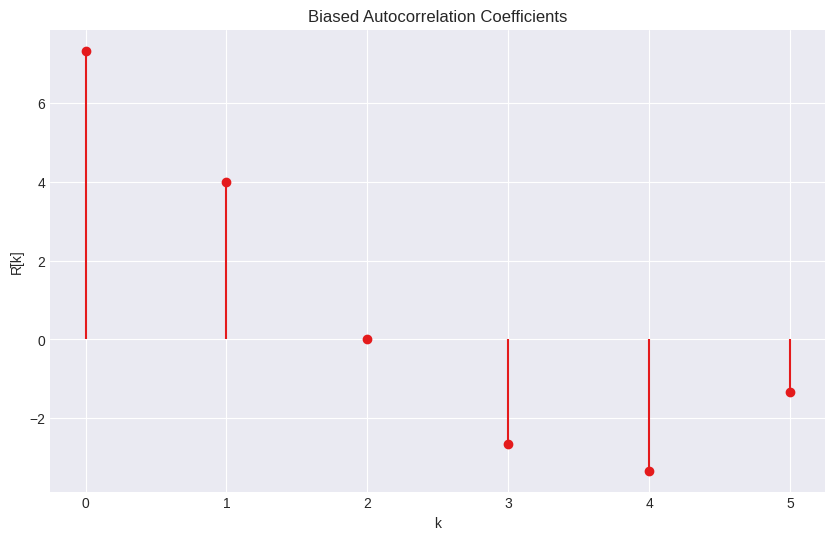

In [60]:
# Plot
plt.figure(figsize=(10, 6))
plt.stem(range(len(R_biased)), R_biased, basefmt=' ')
plt.xlabel('k')
plt.ylabel('R̂[k]')
plt.title('Biased Autocorrelation Coefficients')
plt.grid(True)
plt.show()

### Problem 21: Perform unbiased estimation of its correlation coefficients. Comment on reliability for large k

Proveďte **nevychýlený (unbiased) odhad** jeho korelačních koeficientů. Komentujte spolehlivost tohoto odhadu pro velká $k$:

$$\hat{R}[k] = \frac{1}{N-k} \sum_{n=0}^{N-1} x[n] \cdot x[n+k]$$

**Intuitivně:**

* **Biased:** dělím všude stejnou konstantou → odhad klesá u velkých zpoždění.
* **Unbiased:** dělím přesně podle toho, kolik dat mám → odhad zůstává „spravedlivý“, ale může být hlučnější.

#### Řešení / Solution

**Nevychýlený odhad** (unbiased estimate):

$$\hat{R}[k] = \frac{1}{N-k} \sum_{n=0}^{N-1-k} x[n] \cdot x[n+k]$$

- Jmenovatel se mění s $k$: $(N-k)$
- Statisticky nestranný (nezkreslený)
- **Problém pro velká $k$**: 
  - Pro $k$ blízké $N$ máme jen málo vzorků $(N-k) \to 0$
  - Odhad má vysoký rozptyl a je **nespolehlivý**
  - Pro $k = N-1$ máme pouze jeden vzorek!

Unbiased autocorrelation coefficients:
R̂[0] = 7.3333  (based on 6 samples)
R̂[1] = 4.8000  (based on 5 samples)
R̂[2] = 0.0000  (based on 4 samples)
R̂[3] = -5.3333  (based on 3 samples)
R̂[4] = -10.0000  (based on 2 samples)
R̂[5] = -8.0000  (based on 1 samples)

Comparison:


,k,R_biased,R_unbiased,Samples used
0,0,7.333333,7.333333,6
1,1,4.000000,4.800000,5
2,2,0.000000,0.000000,4
3,3,-2.666667,-5.333333,3
4,4,-3.333333,-10.000000,2
5,5,-1.333333,-8.000000,1


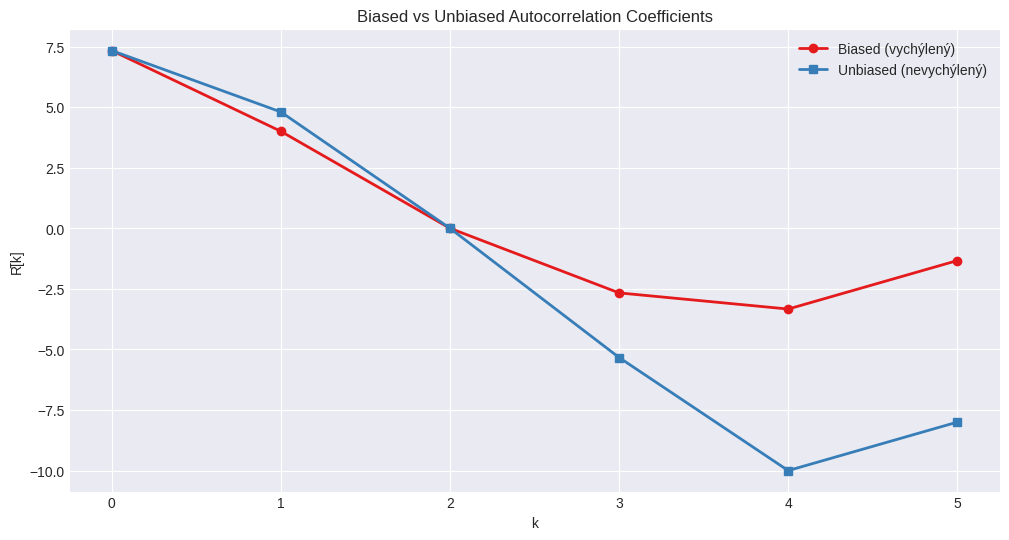

In [65]:
# Solution 21
R_unbiased = autocorr(x, biased=False)

# Display results
print("Unbiased autocorrelation coefficients:")
for k in range(len(R_unbiased)):
    num_samples = N - k
    print(f"R̂[{k}] = {R_unbiased[k]:.4f}  (based on {num_samples} samples)")

print("\nComparison:")
comp_df = pd.DataFrame({
    'k': range(N),
    'R_biased': R_biased,
    'R_unbiased': R_unbiased,
    'Samples used': [N-k for k in range(N)]
})
display(comp_df)

# Plot comparison
plt.figure(figsize=(12, 6))
k_vals = range(len(R_biased))
plt.plot(k_vals, R_biased, 'o-', label='Biased (vychýlený)', linewidth=2)
plt.plot(k_vals, R_unbiased, 's-', label='Unbiased (nevychýlený)', linewidth=2)
plt.xlabel('k')
plt.ylabel('R̂[k]')
plt.title('Biased vs Unbiased Autocorrelation Coefficients')
plt.legend()
plt.grid(True)
plt.show()

**Komentář ke spolehlivosti pro velká $k$:**
Pro velká $k$ se nevychýlený odhad stává méně spolehlivým, protože:
- Počet použitých vzorků klesá ($N-k$ se snižuje)
- Pro $k$ blízké $N$ přispívá k odhadu jen 1 nebo 2 vzorky
- To vede k vysokému rozptylu a nespolehlivým odhadům
- Vychýlený odhad je stabilnější, ale systematicky podhodnocuje $R[k]$



---
## 6. Spektrální hustota výkonu (PSD) / Power spectral density

V tabulce jsou dány koeficienty DFT zadaného signálu $x[n]$ a její moduly:

#### Řešení / Solution

In [67]:
# DFT coefficients
X_k = np.array([
    2.0000 + 0.0000j,
    2.0000 + 10.3923j,
    2.0000 + 3.4641j,
    2.0000 + 0.0000j,
    2.0000 - 3.4641j,
    2.0000 - 10.3923j
])

X_k_mag_sq = np.abs(X_k)**2

# Display table
dft_df = pd.DataFrame({
    'k': range(len(X_k)),
    'X[k]': X_k,
    '|X[k]|²': X_k_mag_sq
})
display(dft_df)

,k,X[k],|X[k]|²
0,0,2.0000+ 0.0000j,4.000000
1,1,2.0000+10.3923j,111.999899
2,2,2.0000+ 3.4641j,15.999989
3,3,2.0000+ 0.0000j,4.000000
4,4,2.0000- 3.4641j,15.999989
5,5,2.0000-10.3923j,111.999899


### Problem 22: Estimate PSD using DFT. Plot for useable frequencies (normalized 0 to 0.5)

Odhadněte spektrální hustotu výkonu pomocí DFT. Nakreslete ji pro použitelné frekvence, tedy normované frekvence od 0 do $\frac{1}{2}$:

$$G\left(\frac{k}{N}\right) = \frac{|X[k]|^2}{N}$$

#### Řešení / Solution

**Spektrální hustota výkonu** (Power Spectral Density - PSD) udává rozložení výkonu signálu v závislosti na frekvenci.

**Odhad pomocí DFT** (periodogram):

$$G(f) = \frac{|X[k]|^2}{N}$$

kde:
- $X[k]$ je DFT signálu $x[n]$
- $N$ je počet vzorků
- Normovaná frekvence: $f = \frac{k}{N}$
- Použitelné frekvence: $0 \leq f \leq 0.5$ (díky symetrii DFT)

Power Spectral Density:


,k,f_norm (k/N),G(k/N)
0,0,0.000000,0.666667
1,1,0.166667,18.666650
2,2,0.333333,2.666665
3,3,0.500000,0.666667


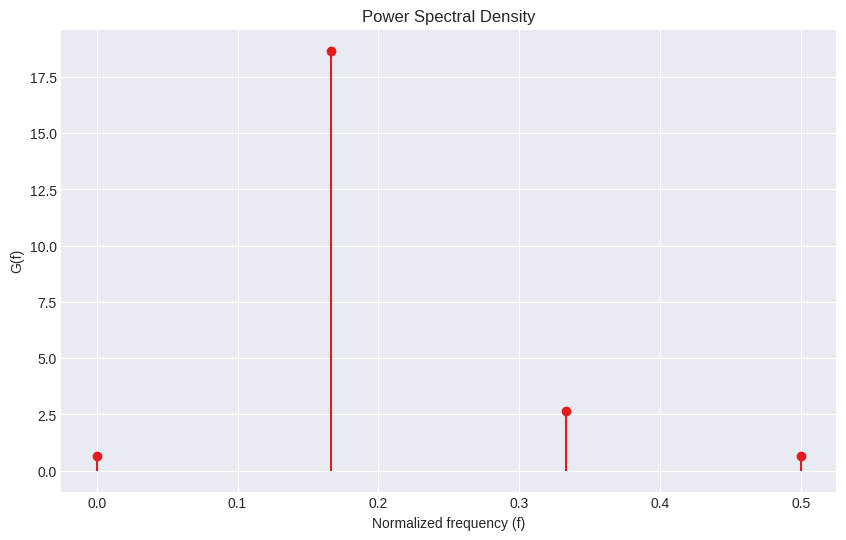

In [69]:
# Solution 22
N_dft = len(X_k)
G_k = X_k_mag_sq / N_dft

# Normalized frequencies
f_norm = np.arange(N_dft) / N_dft

# Take only useable frequencies (0 to 0.5)
useable_idx = f_norm <= 0.5
f_norm_useable = f_norm[useable_idx]
G_k_useable = G_k[useable_idx]

# Display PSD
psd_df = pd.DataFrame({
    'k': np.arange(len(f_norm_useable)),
    'f_norm (k/N)': f_norm_useable,
    'G(k/N)': G_k_useable
})
print("Power Spectral Density:")
display(psd_df)

# Plot PSD
plt.figure(figsize=(10, 6))
plt.stem(f_norm_useable, G_k_useable, basefmt=' ')
plt.xlabel('Normalized frequency (f)')
plt.ylabel('G(f)')
plt.title('Power Spectral Density')
plt.grid(True)
plt.show()

### Problem 23: Determine the normalized frequency of maximum PSD

Určete, na které normované frekvenci leží maximum spektrální hustoty výkonu

#### Řešení / Solution

In [71]:
# Solution 23
max_idx = np.argmax(G_k_useable)
f_max = f_norm_useable[max_idx]
G_max = G_k_useable[max_idx]

print(f"Maximum PSD occurs at:")
print(f"  k = {max_idx}")
print(f"  Normalized frequency f = k/N = {f_max}")
print(f"  PSD value G(f) = {G_max}")

Maximum PSD occurs at:
  k = 1
  Normalized frequency f = k/N = 0.16666666666666666
  PSD value G(f) = 18.666649881666668


### Problem 24: Verify that this frequency approximately corresponds to how x[n] is periodic

Ověřte, že frekvence odpovídá zhruba tomu, jak je $x[n]$ periodický

#### Řešení / Solution

**Vztah mezi frekvencí a periodou**:

$$f = \frac{1}{T}$$

kde:
- $f$ je frekvence (normovaná)
- $T$ je perioda v počtu vzorků

Pokud má signál periodu $T$ vzorků, mělo by maximum PSD ležet na frekvenci $f \approx \frac{1}{T}$.

Verification:
Signal x[n] = [ 2  4  2  0 -2 -4]

The signal appears to be periodic with period ~ 8 samples (one full cycle)
However, looking more carefully:
  x[0]=2, x[1]=4, x[2]=2, x[3]=0, x[4]=-2, x[5]=-4

This resembles a sinusoid with period ≈ 8 samples
The fundamental frequency would be f = 1/8 = 0.125. (not far from 1/6)

The maximum in PSD is at f = 0.16666666666666666
This corresponds to a period of 1/0.16666666666666666 = 6.0 samples


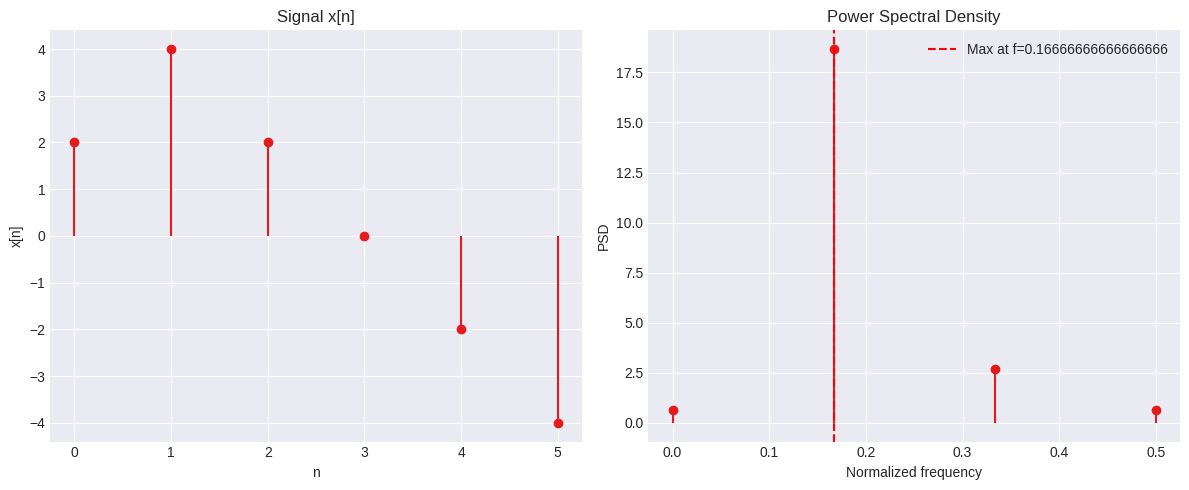

In [74]:
# Solution 24
print("Verification:")
print(f"Signal x[n] = {x}")
print(f"\nThe signal appears to be periodic with period ~ 8 samples (one full cycle)")
print(f"However, looking more carefully:")
print(f"  x[0]=2, x[1]=4, x[2]=2, x[3]=0, x[4]=-2, x[5]=-4")
print(f"\nThis resembles a sinusoid with period ≈ 8 samples")
print(f"The fundamental frequency would be f = 1/8 = 0.125. (not far from 1/6)")
print(f"\nThe maximum in PSD is at f = {f_max}")
print(f"This corresponds to a period of 1/{f_max} = {1/f_max if f_max > 0 else 'inf'} samples")

# Plot signal to visualize periodicity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(range(len(x)), x, basefmt=' ')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('Signal x[n]')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(f_norm_useable, G_k_useable, basefmt=' ')
plt.axvline(f_max, color='r', linestyle='--', label=f'Max at f={f_max}')
plt.xlabel('Normalized frequency')
plt.ylabel('PSD')
plt.title('Power Spectral Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 7. Průchod náhodného signálu filtrem / Filtering of a random signal

### Problem 25: Signal x[n] is filtered by H(z) = 1 - z⁻¹. Determine if and how the maximum of its PSD will change

Signál $x[n]$ je filtrován filtrem s přenosovou funkcí $H(z) = 1 - z^{-1}$. Určete, zda a jak se změní maximum jeho PSD

#### Řešení / Solution

**PSD výstupního signálu** po průchodu lineárním filtrem:

$$G_y(f) = |H(f)|^2 \cdot G_x(f)$$

kde:
- $G_x(f)$ je PSD vstupního signálu
- $G_y(f)$ je PSD výstupního signálu
- $H(f)$ je frekvenční charakteristika filtru
- $|H(f)|^2$ je kvadrát amplitudové frekvenční charakteristiky

Pro filtr $H(z) = 1 - z^{-1}$:

$$H(e^{j\omega}) = 1 - e^{-j\omega}$$
$$|H(e^{j\omega})|^2 = |1 - e^{-j\omega}|^2$$

Tento filtr je **high-pass filtr**, který:
- Potlačuje nízké frekvence ($|H(0)|^2 = 0$)
- Propouští vysoké frekvence ($|H(\pi)|^2 = 4$)

In [81]:
# Solution 25
# Filter transfer function H(z) = 1 - z^(-1)
# Frequency response: H(e^(jω)) = 1 - e^(-jω)

# Given help table
omega_values = np.array([0, 2*np.pi/6, 4*np.pi/6, 6*np.pi/6])
H_omega = np.array([
    0.0000 + 0.0000j,
    0.5000 + 0.8660j,
    1.5000 + 0.8660j,
    2.0000 + 0.0000j
])
H_mag_sq = np.abs(H_omega)**2

# Display help table
help_df = pd.DataFrame({
    'ω [rad]': omega_values,
    'ω/π': omega_values / np.pi,
    '1 - e^(-jω)': H_omega,
    '|1 - e^(-jω)|²': H_mag_sq
})
print("Filter frequency response (from help table):")
display(help_df)

# Map to normalized frequencies
f_norm_filter = omega_values / (2 * np.pi)


Filter frequency response (from help table):


,ω [rad],ω/π,1 - e^(-jω),|1 - e^(-jω)|²
0,0.000000,0.000000,0.000+0.000j,0.000000
1,1.047198,0.333333,0.500+0.866j,0.999956
2,2.094395,0.666667,1.500+0.866j,2.999956
3,3.141593,1.000000,2.000+0.000j,4.000000


In [82]:
# PSD of output: G_y(f) = |H(f)|² * G_x(f)
# We need to evaluate |H(f)|² at the frequencies of our signal

print("\nAnalysis:")
print(f"Input signal x[n] has maximum PSD at f = {f_max}")
print(f"This corresponds to ω = 2πf = {2*np.pi*f_max} rad")

# Interpolate |H(f)|² at f_max
omega_max = 2 * np.pi * f_max
H_mag_sq_at_max = np.interp(omega_max, omega_values, H_mag_sq)
print(f"\n|H(f)|² at f = {f_max}: {H_mag_sq_at_max}")

# Compute output PSD
G_y = np.interp(f_norm_useable * 2 * np.pi, omega_values, H_mag_sq) * G_k_useable

# Find new maximum
max_idx_y = np.argmax(G_y)
f_max_y = f_norm_useable[max_idx_y]
G_max_y = G_y[max_idx_y]

print(f"\nOutput signal y[n]:")
print(f"  Maximum PSD at f = {f_max_y}")
print(f"  PSD value = {G_max_y}")

print(f"\nZávěr / Conclusion:")
if f_max != f_max_y:
    print(f"  Maximum frekvence se ZMĚNILO z {f_max} na {f_max_y}")
else:
    print(f"  Maximum frekvence ZŮSTALO na {f_max}")
print(f"  Filtr H(z) = 1 - z⁻¹ je high-pass filtr (diferenciátor)")
print(f"  Potlačuje nízké frekvence a propouští vysoké frekvence")



Analysis:
Input signal x[n] has maximum PSD at f = 0.16666666666666666
This corresponds to ω = 2πf = 1.0471975511965976 rad

|H(f)|² at f = 0.16666666666666666: 0.9999560000000001

Output signal y[n]:
  Maximum PSD at f = 0.16666666666666666
  PSD value = 18.665828549071875

Závěr / Conclusion:
  Maximum frekvence ZŮSTALO na 0.16666666666666666
  Filtr H(z) = 1 - z⁻¹ je high-pass filtr (diferenciátor)
  Potlačuje nízké frekvence a propouští vysoké frekvence


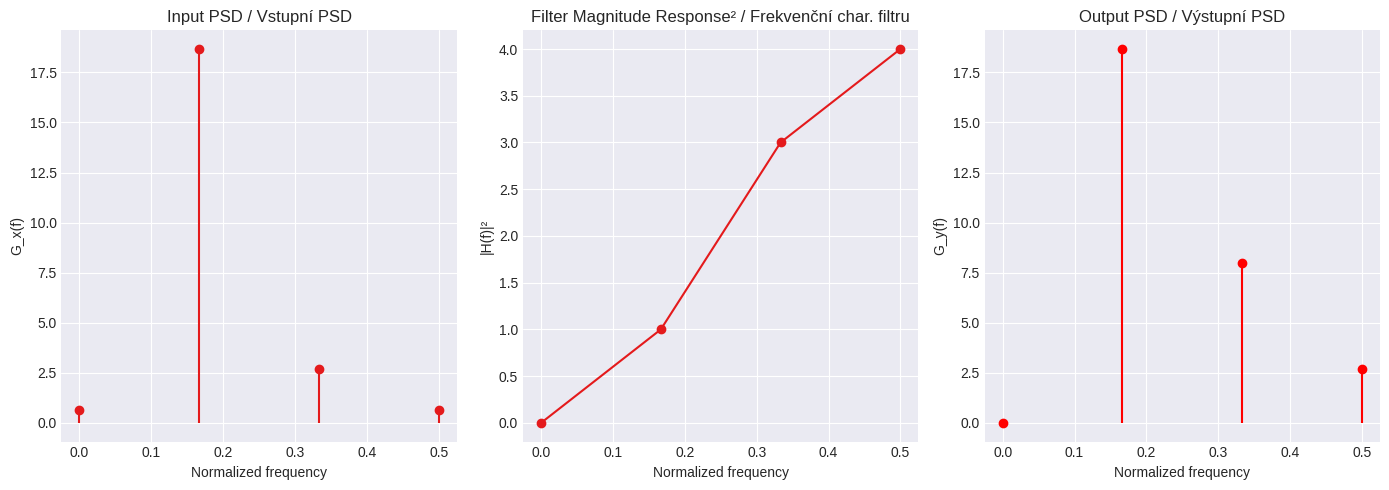

In [83]:
# Plot comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.stem(f_norm_useable, G_k_useable, basefmt=' ')
plt.xlabel('Normalized frequency')
plt.ylabel('G_x(f)')
plt.title('Input PSD / Vstupní PSD')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(f_norm_filter, H_mag_sq, 'o-')
plt.xlabel('Normalized frequency')
plt.ylabel('|H(f)|²')
plt.title('Filter Magnitude Response² / Frekvenční char. filtru')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(f_norm_useable, G_y, basefmt=' ', linefmt='r-', markerfmt='ro')
plt.xlabel('Normalized frequency')
plt.ylabel('G_y(f)')
plt.title('Output PSD / Výstupní PSD')
plt.grid(True)

plt.tight_layout()
plt.show()